In [3]:
! pip install spacy

In [8]:
import os
import csv
import spacy

class Corpus(object):
  def __init__(self,filename):
    self.filename=filename
    self.nlp=spacy.blank("en")
  def __iter__(self):
    with open(self.filename,"r") as i:
      reader=csv.reader(i,delimiter=",")
      for _, abstract in reader:
        tokens=[t.text.lower() for t in self.nlp(abstract)]
        yield tokens


documents=Corpus("/content/arxiv.csv")
#this reads the entire dataset and with the help of nlp steps it converts the dataset into tokens for each words

In [9]:
documents = list(documents)
documents[:10]


[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [11]:
! pip install spacy gensim
#it is used for embeddings vectorization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.6 MB/s eta 0:00:00


In [12]:
import gensim

model = gensim.models.Word2Vec(documents, min_count=100, window=5, vector_size=100)

In [13]:
model.wv["nlp"]

array([ 5.89026749e-01, -1.81973612e+00,  2.19951820e+00, -2.26012990e-01,
       -6.68477938e-02, -9.35109615e-01,  2.00192571e+00, -8.87167871e-01,
        4.92743462e-01,  2.82451248e+00,  4.95004028e-01,  5.81658483e-02,
        8.30311418e-01, -7.10488439e-01,  4.02796090e-01, -5.60396463e-02,
       -1.09417081e+00,  1.04996669e+00,  1.93290398e-01,  1.49503958e+00,
        1.05493712e+00, -1.11954324e-01,  5.25582552e-01,  4.09361541e-01,
       -2.77343464e+00, -1.10022390e+00,  1.09099162e+00,  1.74996531e+00,
        3.19774485e+00,  2.80572742e-01,  8.60336125e-01,  4.20965590e-02,
        7.00738132e-01, -2.28199840e-01,  6.87986255e-01, -1.23113585e+00,
        4.73658144e-01, -5.27860403e+00,  3.47387731e-01,  8.64126146e-01,
       -1.61498678e+00, -1.71779180e+00,  3.68345833e+00,  7.27190912e-01,
       -1.50921166e+00,  3.01605612e-01,  2.70577288e+00,  7.26171434e-01,
       -1.32573485e+00, -1.07830358e+00,  2.25867891e+00,  3.51052731e-01,
        1.04917598e+00, -

In [14]:
print(model.wv.similarity("nmt","smt"))
#for the 2 words it finds the cosine similarity and returns the similarity value with the help of individual vectors.If distance between vectors is less ,similarity is more
print(model.wv.similarity("nmt","ner"))

0.6644839
0.42243892


In [15]:
model.wv.similar_by_word("bert", topn = 10)
#it displays the top 10 similar words for the word "bert"

[('roberta', 0.7854173183441162),
 ('transformer', 0.7695328593254089),
 ('transformers', 0.7283595204353333),
 ('elmo', 0.693354070186615),
 ('pretrained', 0.6836634874343872),
 ('xlnet', 0.6615235209465027),
 ('gpt-2', 0.6383979916572571),
 ('xlm', 0.6357436180114746),
 ('lstm', 0.6248416900634766),
 ('mbert', 0.6205247044563293)]

In [16]:
model.wv.most_similar(positive=["transformer", "lstm"], negative=["bert"])
#it displays the similar words for "transformmer" and "lstm" and dissimilar to "bert"

[('rnn', 0.8258426189422607),
 ('recurrent', 0.7439377307891846),
 ('gru', 0.743445098400116),
 ('attentional', 0.7299028635025024),
 ('bilstm', 0.697523295879364),
 ('gated', 0.680027186870575),
 ('convolution', 0.6776396036148071),
 ('convolutional', 0.6724761128425598),
 ('stacked', 0.6715186238288879),
 ('directional', 0.6664844751358032)]

In [17]:
model.wv.most_similar(positive=["tree"], topn=10)

[('trees', 0.7982971668243408),
 ('constituency', 0.7267128229141235),
 ('parse', 0.7096396684646606),
 ('recursive', 0.6791876554489136),
 ('constituent', 0.6671802401542664),
 ('dependency', 0.6640447378158569),
 ('syntax', 0.616194486618042),
 ('path', 0.6129019260406494),
 ('grammar', 0.6066630482673645),
 ('parser', 0.6050172448158264)]

In [18]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split()))
#for this sentence it calculates an average vector and compare with the each word vector and returns the more distance word(doesnot match)
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))

svm
word2vec
bert


In [21]:
%matplotlib inline

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word], topn=200)] + [target_word]
embeddings = [model.wv[w] for w in selected_words] + model.wv["bert"]

mapped_embeddings = TSNE(n_components=2, metric='cosine', init='pca').fit_transform(embeddings)
#pca is used for reduction of the dimension needed enough for the graph
#for eg if there are 10 dimension and i need only 2 dimension means with the help of pca i can reduce the dimension

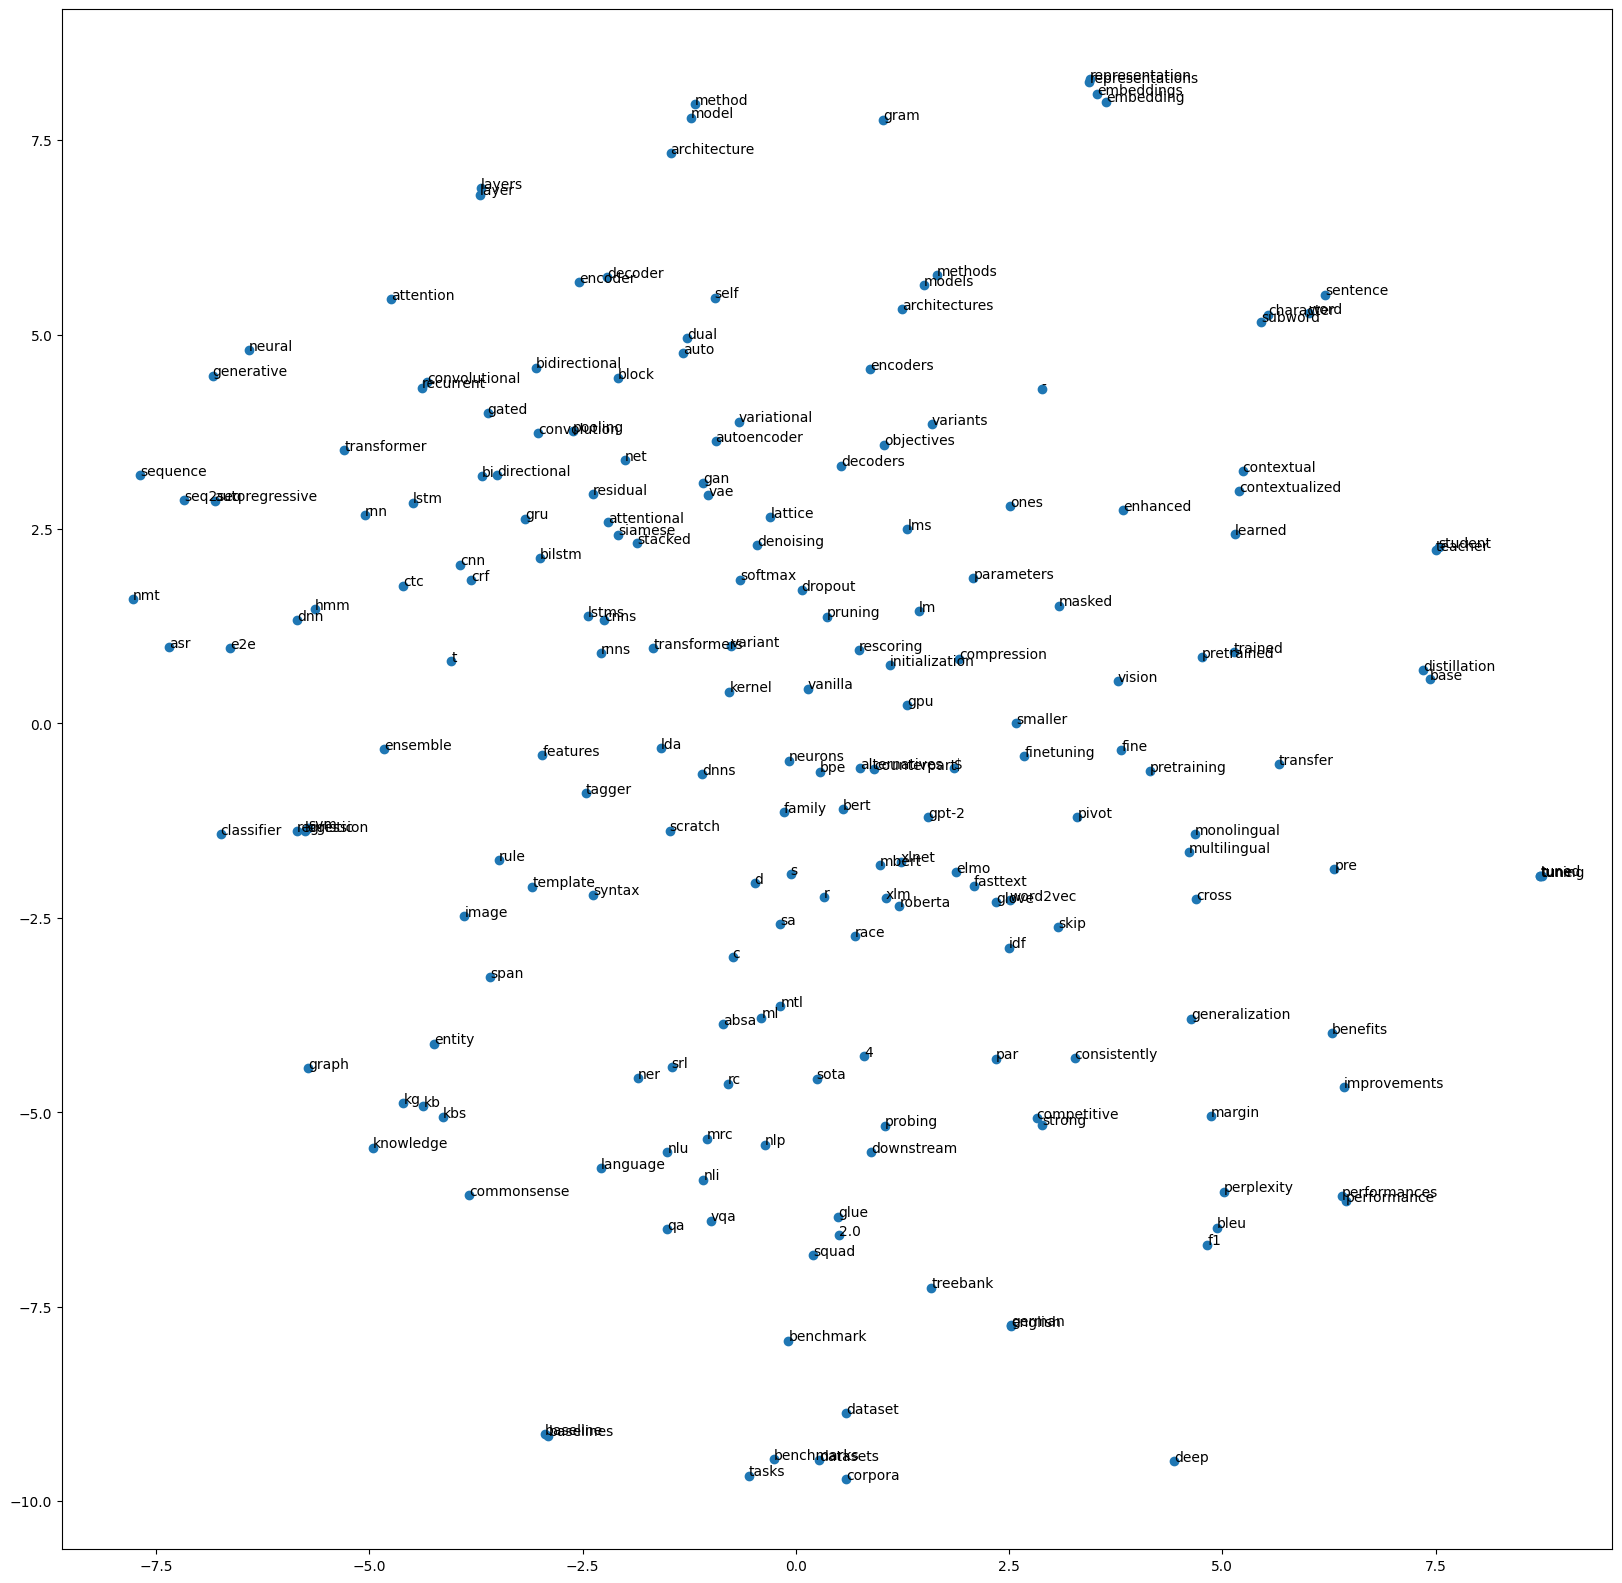

In [20]:
plt.figure(figsize=(20,20))
x = mapped_embeddings[:,0]
y = mapped_embeddings[:,1]
plt.scatter(x,y)

for i,txt in enumerate(selected_words):
  plt.annotate(txt, (x[i], y[i]))